# Aquamatch Data

The Aquamatch data is a repository of mostly inland chlorophyll data used for satellite matchup. Similar to data such as CalCOFI and HOTS, this dataset is highly QA/QCd and so it's easy to go through their documentation and remove any flagged chlorophyll data. Even though the dataset is mostly inland, there is some chlorophyll data in coastal regions. 

link to dataset: https://portal.edirepository.org/nis/mapbrowse?packageid=edi.1756.2

link to paper: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2019WR024883

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
#limit data to just the coastal region
aqua_match1 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\one off cruises\AquaMatch_chl.xlsx') #read in datafile

#subset to just the coastal waters 
shp1 = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf1 = gpd.GeoDataFrame(aqua_match1, geometry=gpd.points_from_xy(aqua_match1.lon, aqua_match1.lat), crs="EPSG:4269")
gdf1 = gdf1.to_crs(shp1.crs)
aqua_match1 = gpd.clip(gdf1,shp1)

In [ ]:
#reduce dataframe to only needed columns for easier manipulation and rename columns to match seabass file structure
aqua_match1=aqua_match1[[ 'OrganizationIdentifier','field_flag','tier', 'harmonized_utc', 'harmonized_discrete_depth_value',  'harmonized_value', 'lat','lon']]
aqua_match1=aqua_match1.rename(columns={'OrganizationIdentifier':'station','harmonized_utc':'datetime','harmonized_discrete_depth_value':'depth',
                                      'harmonized_value':'chl','field_flag':'flag'})
aqua_match1['datetime'] = pd.to_datetime(aqua_match1['datetime']) #ensure datetime column is in pandas datetime format and datatype 

#for this project, only want data from 2000 thru 2024 
aqua_match1 = aqua_match1[(aqua_match1['datetime'] >= pd.to_datetime('2000-01-01 00:00:00').tz_localize('UTC')) & (aqua_match1['datetime'] <= pd.to_datetime('2025-01-01 00:00:00').tz_localize('UTC'))]


To ensure that the metadata was correctly filled out, the station code from the water quality website: https://www.waterqualitydata.us/provider/STORET/ was used to identify the affiliated parties and added to a column of the dataframe

In [ ]:
aqua_match1['affiliations']=np.nan
aqua_match1.affiliations[(aqua_match1['station'] =='21FLKWAT') | (aqua_match1['station'] =='21FLKWAT_WQX')] = 'Florida Lakewatch'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLKNMS_WQX')] = 'FLORIDA KEYS NATIONAL MARINE SANCTUARY'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLFMRI')] = 'Florida Fish & Wildlife C C / Marine Research Institute'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLFTM_WQX')] = 'FL Dept. of Environmental Protection, South District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLDADE_WQX') | (aqua_match1['station'] =='21FLDADE')] = 'Dade Environmental Resource Management'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLBBAP_WQX')] = 'FDEP BISCAYNE BAY AQUATIC PRESERVES'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCOMI_WQX')] = 'CITY OF MARCO ISLAND'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLBRA')] = 'Biological Research Associates'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLNAPL_WQX')] = 'City of Naples'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLEECO_WQX')] = 'Lee County'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCHAR_WQX') | (aqua_match1['station'] =='21FLCHAR')] = 'FDEP Charlotte Harbor Aquatic/Buffer Preserves'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPBCH_WQX') | (aqua_match1['station'] =='21FLPBCH')] = 'Palm Beach County Environmental Resources Managemnt'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLLOX_WQX') | (aqua_match1['station'] =='21FLLOX')] = 'Loxahatchee River District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLSARA') | (aqua_match1['station'] =='21FLSARA_WQX')] = 'Sarasota County Environmental Services'
aqua_match1.affiliations[(aqua_match1['station'] =='11NPSWRD_WQX')] = 'National Park Service Water Resources Division'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLMANA_WQX') | (aqua_match1['station'] =='21FLMANA')] = 'Manatee County Environmental Management Dept'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLHILL_WQX')] = 'Environmental Protection Commission of Hillsborough County'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPDEM') | (aqua_match1['station'] =='21FLPDEM_WQX')] = 'Pinellas County Dept. of Environmental Management'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLBSG')] = 'City of Tampa Bay Study Group'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCOSP_WQX')] = 'City of St Petersburg'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLGW_WQX')] = 'FL Dept. of Environmental Protection'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCEN_WQX')] = 'Fl Dept. of Environmental Protection, Central District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCEN_WQX')] = 'Fl Dept. of Environmental Protection, Central District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLBREV_WQX') | (aqua_match1['station'] =='21FLBREV')] = 'Brevard County Stormwater Utility Department'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPCSW') | (aqua_match1['station'] =='21FLPCSW_WQX')] = 'PROJECT COAST - Southwest Florida Water Management District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLA_WQX')] = 'FL Dept. of Environmental Protection, Northeast District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLANER') | (aqua_match1['station'] =='21FLANER_WQX')] = 'FDEP APALACHICOLA NATIONAL ESTUARINE RESEARCH RESERVE'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLNWFD')] = 'Northwest Florida Water District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPNS_WQX')] = 'FL Dept. of Environmental Protection, Northwest District'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLGTM') | (aqua_match1['station'] =='21FLGTM_WQX')] = 'GUANA TOLOMATO MATANZAS NATIONAL ESTUARINE RESEARCH RESERVE'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPNS_WQX')] = 'ALABAMA DEPT. OF ENVIRONMENTAL MANAGEMENT'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLPNS_WQX')] = 'National Health and Environmental Effect Research-NHEERL'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLGBO1')] = 'National Health and Environmental Effect Research-NHEERL'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLECUA_WQX')] = 'EMERALD COAST UTLITIES AUTHORITY'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLESC_WQX')] = 'ESCAMBIA COUNTY'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCBA_WQX') | (aqua_match1['station'] =='21FLCBA')] = 'Choctawhatchee Basin Alliance'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLNUTT_WQX')] = 'NUTTER AND ASSOCIATES'
aqua_match1.affiliations[(aqua_match1['station'] =='21FLCMP_WQX')] = 'FL Dept. of Environmental Protection, OCEC '
aqua_match1.affiliations[(aqua_match1['station'] =='21FLFRYD_WQX')] = 'FRYDENBORG ECOLOGIC LLC'
aqua_match1.affiliations[(aqua_match1['station'] =='21DELAWQ_WQX')] = 'Delaware Dept Natural Resources &amp; Environmental Control'


from the aquamatch metadata file: chl_a workflow, flags are used to check if data is reasonable (flag = 0), suspect (flag = 1), or inconclusive (flag = 2). So remove all bad flags from the dataset. 
- flag defs from this website:https://portal.edirepository.org/nis/metadataviewer?packageid=edi.1756.2

In [ ]:
#Remove bad flags 
aqua_match1 = aqua_match1[aqua_match1['flag'] != 1]
aqua_match1 = aqua_match1[aqua_match1['flag'] != 2] 
aqua_match1 = aqua_match1[aqua_match1['tier'] != 2] 

In [ ]:
#only want points above 150 meters for algorithm development
aqua_match1 = aqua_match1[aqua_match1['depth'] <=150]
    
#while the aquamatch doi mentions HPLC, it seems like the flags for if the CHL sample was HPLC or not is buried in the metadata and not saved 
# to this dataset, and so there is no definitive way of distinguishing HPLC from non HPLC. Therefore, assume no HPLC
aqua_match1['HPLC']=1
#triplicate flag 
counts_series = aqua_match1[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq') #create new column where each unique entry aso shows howmany times that entry was recorded 
aqua_match1 = pd.merge(aqua_match1, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
aqua_match1['date_hour'] = aqua_match1['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = aqua_match1[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
aqua_match1 = pd.merge(aqua_match1, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe

aqua_match1['triplicate'] = 1 #assume bad unless otherwise said
aqua_match1.loc[aqua_match1['freq_uniq'] == 3, 'triplicate'] = 0 #if there are exactly 3 unique datetime, lat, and lons, assume triplicate
aqua_match1.loc[(aqua_match1['freq_uniq'] == 1) &(aqua_match1['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime BUT 3 unique date_hours, assume triplicate

#reduce columns to only needed ones
aqua_match1=aqua_match1[['station', 'datetime', 'depth','chl', 'lat', 'lon', 'affiliations','HPLC','triplicate']].reset_index(drop=True)
aqua_match1['source']='AquaMatch'
aqua_match1['investigators']= 'Brousil, Matthew R'
aqua_match1['url']='https://doi.org/10.6073/pasta/2f750544112e5408928dd9a61e6ace30'
aqua_match1['datetime'] = aqua_match1['datetime'].dt.tz_localize(None) 

Congrats on having all coastal chlorophyll data from aquamatch!!

Ross, M. R. V., Topp, S. N., Appling, A. P., Yang, X., Kuhn, C., Butman, D. et al. (2019). AquaSat: A data set to enable remote sensing of water quality for inland waters. Water Resources Research, 55, 10012–10025. https://doi.org/10.1029/2019WR024883

## Plots

In [2]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')


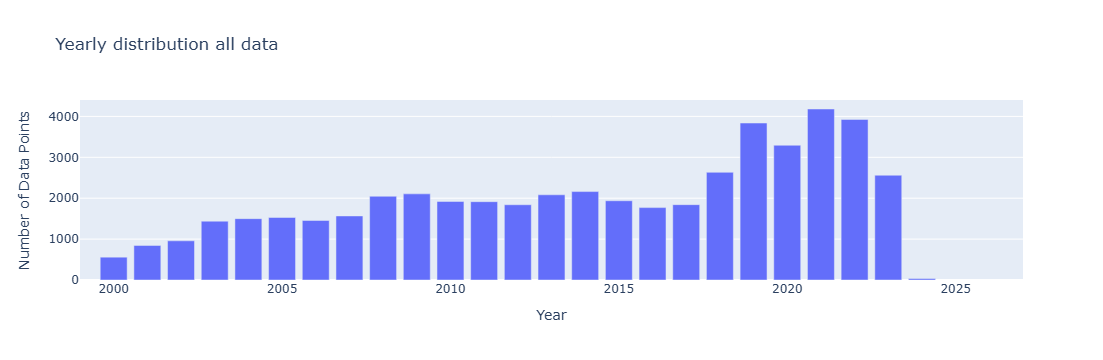

In [3]:
year_test=aqua.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

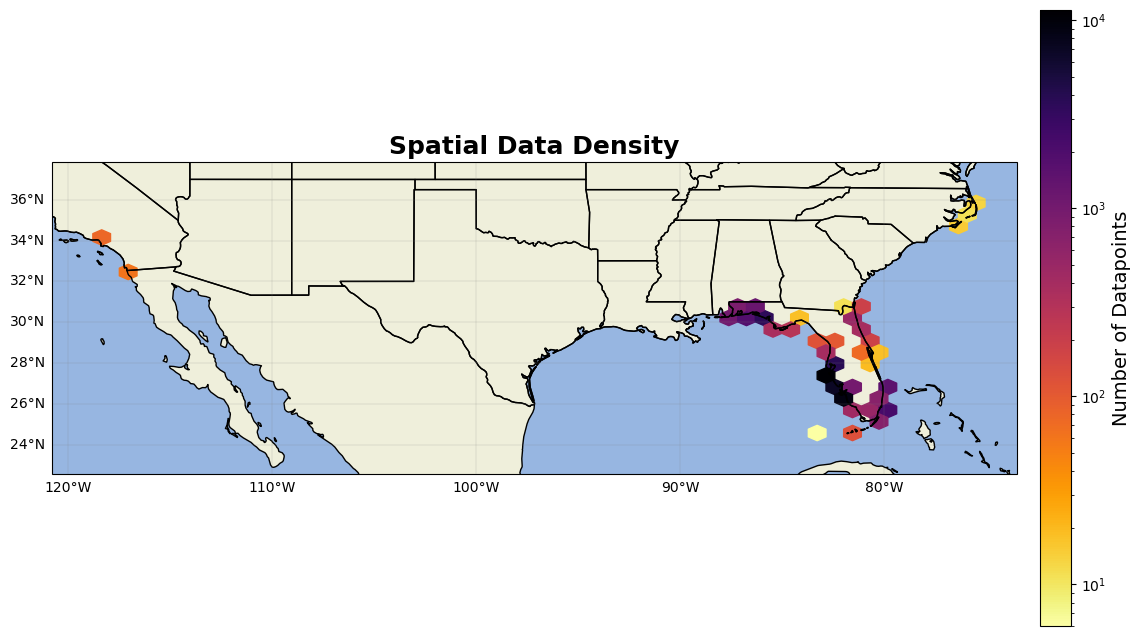

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(50,10), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()